# Machines mathématiques avec Flax NNX

Flax aide à construire des machines paramétrées à partir de couches élémentaires. Nous utilisons son interface NNX : une machine est un objet Python que l'on peut évaluer, différencier et ajuster.

Le but de ce notebook tient en une phrase : **définir en quelques lignes une machine mathématique, puis apprendre ses paramètres à partir de données**.

À la fin de ce notebook, vous devriez savoir :

- définir un perceptron multicouche (`'multilayer perceptron'`, MLP) avec `nnx.Module` ;
- relier ses couches à l'écriture mathématique de la machine ;
- identifier ses paramètres $p$ ;
- effectuer un apprentissage avec `nnx.value_and_grad`, Optax et `nnx.Optimizer`.

## Exercices

1. [Une couche affine](#Exercice-1)
2. [La classe de machines compte](#Exercice-2)

In [ ]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import flax
from flax import nnx

print(f"JAX {jax.__version__}, Flax {flax.__version__}, Optax {optax.__version__}")

JAX 0.11.1, Flax 0.12.9, Optax 0.2.8


## 1. Définir une machine

Nous considérons une machine $M_p:\mathbb R\to\mathbb R$ de la forme

$$
M_p(x)=W_2\tanh(W_1x+b_1)+b_2.
$$

Le paramètre $p$ rassemble les matrices et les vecteurs $(W_1,b_1,W_2,b_2)$. La dimension de l'espace intermédiaire est appelée `largeur` dans le programme.

In [2]:
class PerceptronMulticouche(nnx.Module):
    def __init__(self, largeur, *, rngs):
        self.affine_1 = nnx.Linear(1, largeur, rngs=rngs)
        self.affine_2 = nnx.Linear(largeur, 1, rngs=rngs)

    def __call__(self, x):
        return self.affine_2(jnp.tanh(self.affine_1(x)))

Une classe dérivée de `nnx.Module` décrit un module (`'module'`) que l'on peut composer avec d'autres modules. La méthode `__call__` décrit l'évaluation de la machine (`'forward pass'`).

Malgré son nom, `nnx.Linear` représente par défaut une application **affine**, avec une matrice `kernel` et un vecteur `bias`. NNX emploie des vecteurs-lignes et calcule `x @ kernel + bias`. Avec la convention du cours en vecteurs-colonnes, on a donc $W=\mathtt{kernel}^\top$.

L'objet `nnx.Rngs(0)` fournit une suite reproductible de clés pour initialiser les paramètres aléatoires.

In [3]:
machine = PerceptronMulticouche(largeur=32, rngs=nnx.Rngs(0))
x_test = jnp.array([[-1.0], [0.0], [1.0]])

print(f"forme de x : {x_test.shape}")
print(f"forme de M_p(x) : {machine(x_test).shape}")
print(f"W_1 : {machine.affine_1.kernel[...].shape}")
print(f"b_1 : {machine.affine_1.bias[...].shape}")
print(f"W_2 : {machine.affine_2.kernel[...].shape}")
print(f"b_2 : {machine.affine_2.bias[...].shape}")

forme de x : (3, 1)
forme de M_p(x) : (3, 1)
W_1 : (1, 32)
b_1 : (32,)
W_2 : (32, 1)
b_2 : (1,)


### Exercice 1

**Une couche affine.**

Construisez `affine = nnx.Linear(2, 3, rngs=nnx.Rngs(1))` et choisissez un tableau `x` de forme `(4, 2)`. Vérifiez directement que

```python
affine(x) == x @ affine.kernel[...] + affine.bias[...]
```

Expliquez les formes de tous les tableaux et donnez les dimensions de l'application affine correspondante.

In [ ]:
# À compléter.

## 2. Données et fonction objectif

Nous observons la fonction

$$
f(x)=\sin(2\pi x)+0.3x
$$

en $n_{\mathcal D}=129$ points. Les tableaux ont la forme `(129, 1)` : le premier axe parcourt les données et le second représente la dimension de l'espace de départ ou d'arrivée.

In [5]:
def cible(x):
    return jnp.sin(2.0 * jnp.pi * x) + 0.3 * x

x_observe = jnp.linspace(-1.0, 1.0, 129).reshape(-1, 1)
z_observe = cible(x_observe)

La fonction objectif est l'erreur quadratique moyenne. Elle dépend de tous les paramètres $p$ contenus dans `machine`, même si nous ne les réunissons pas explicitement dans un vecteur.

In [6]:
def cout(machine, x, z):
    residu = machine(x) - z
    return 0.5 * jnp.mean(residu**2)

print(f"coût initial : {cout(machine, x_observe, z_observe):.3e}")

coût initial : 5.856e-01


## 3. Apprendre les paramètres

Les matrices et les biais créés par `nnx.Linear` sont des variables de type `nnx.Param`. L'argument `wrt=nnx.Param` indique que ce sont elles que l'optimiseur doit ajuster.

La transformation `nnx.value_and_grad` calcule simultanément le coût et son gradient par rapport à ces paramètres. `nnx.Optimizer` associe la transformation Optax à son état interne. Sa méthode `update` modifie la machine et l'état de l'optimiseur **en place** : c'est ici que la mutabilité des objets Python, vue dans le notebook 00, intervient.

Enfin, `@nnx.jit` joue le même rôle que `@jax.jit`, tout en propageant les modifications des objets NNX hors de la fonction compilée.

In [7]:
alpha = 1.0e-2
optimiseur = nnx.Optimizer(machine, optax.adam(alpha), wrt=nnx.Param)

@nnx.jit
def pas_apprentissage(machine, optimiseur, x, z):
    valeur, gradient = nnx.value_and_grad(cout)(machine, x, z)
    optimiseur.update(machine, gradient)
    return valeur

La boucle d'apprentissage ne contient plus aucun calcul propre au réseau : elle répète simplement le pas précédent.

In [8]:
historique = []
for _ in range(1500):
    valeur = pas_apprentissage(machine, optimiseur, x_observe, z_observe)
    historique.append(float(valeur))

print(f"coût final : {cout(machine, x_observe, z_observe):.3e}")

coût final : 7.495e-05


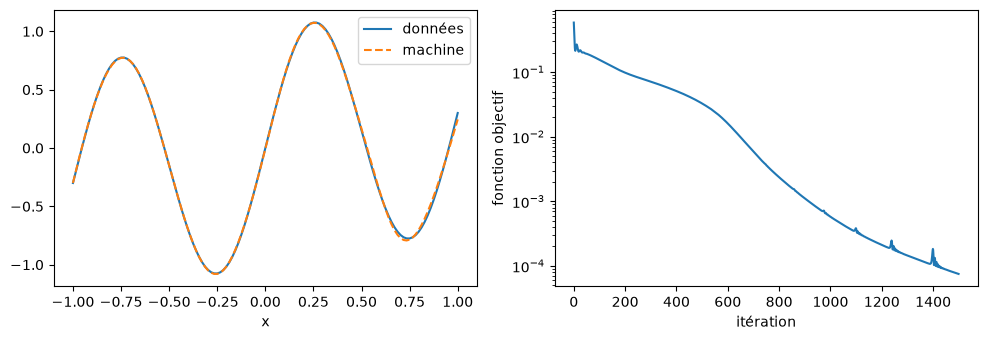

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(x_observe[:, 0], z_observe[:, 0], label="données")
axes[0].plot(x_observe[:, 0], machine(x_observe)[:, 0], "--", label="machine")
axes[0].set_xlabel("x")
axes[0].legend()

axes[1].semilogy(historique)
axes[1].set_xlabel("itération")
axes[1].set_ylabel("fonction objectif")

fig.tight_layout()

Il faut bien distinguer les rôles : Flax organise la machine et ses paramètres, JAX calcule le gradient et compile le pas, tandis qu'Optax transforme le gradient en une mise à jour. NNX relie ces objets sans nous obliger à manipuler nous-mêmes l'arborescence de paramètres.

### Exercice 2

**La classe de machines compte.**

Définissez une classe `MachineAffine` contenant une seule couche `nnx.Linear(1, 1)`. Ajustez-la aux mêmes données avec le même pas d'apprentissage et comparez son coût final à celui du perceptron multicouche.

Pourquoi prolonger l'apprentissage ne permet-il pas de supprimer l'écart restant ? Est-ce une limitation de la méthode d'optimisation ou de la classe de machines ?

In [ ]:
# À compléter.

## Bilan

La classe Python définit la classe de machines $\{M_p\}$, l'appel `machine(x)` évalue $M_p(x)$ et `nnx.value_and_grad` calcule le gradient de la fonction objectif par rapport à $p$. Avec `nnx.Optimizer`, quelques lignes suffisent alors pour apprendre ces paramètres.

La simplicité du programme ne fait pas disparaître les questions mathématiques : choix de la classe de machines, qualité des données, fonction objectif et comportement de la méthode d'optimisation. Elle permet au contraire de les expérimenter directement.